## Tables

In [5]:
import pandas as pd

# Define mappings for shortening dataset names
dataset_mapping = {
    "ECG200": "ECG",
    "EOGHorizontalSignal": "EOGH",
    "EOGVerticalSignal": "EOGV",
    "Epilepsy": "EPI",
    "CinCECGTorso": "CET",
    "ECG5000": "ECG5",
    "ECGFiveDays": "ECGFD",
    "StandWalkJump": "SWJ",
    "TwoLeadECG": "TECG",
    "NerveDamage": "ND",
    "MedicalImages": "MI",
    "Colposcopy": "COL",
    "EyesOpenShut": "EOS",
    "ToeSegmentation1": "TOE",
    "Heartbeat": "HRT",
    "EMOPain": "EMO",
    "HandMovementDirection": "HMD"
}

# Load the CSV file
df = pd.read_csv('article_results\\final_results.csv')


In [6]:
# Group by dataset to get unique datasets
grouped = df.groupby('dataset').first().reset_index()

# Initialize a list to store table rows
table_rows = []

# Iterate over each dataset
for _, row in grouped.iterrows():
    dataset_name = row['dataset']
    # Add the shortened name in parentheses
    shortened_name = dataset_mapping.get(dataset_name, dataset_name)  # Use original name if no mapping exists
    dataset_name_formatted = f"{dataset_name} ({shortened_name})"
    
    n_variates = int(row['n_variates'])  # Number of variates (e.g., 1 for univariate)
    ts_length = int(row['ts_length'])    # Time series length
    n_classes = int(row['n_classes'])    # Number of classes
    
    # Calculate train and test sizes (80/20 split)
    total_samples = int(row['df_size'])
    train_size = int(total_samples * 0.8)
    test_size = total_samples - train_size
    
    # Format train and test shapes
    train_shape = f"({train_size}, {n_variates}, {ts_length})"
    test_shape = f"({test_size}, {n_variates}, {ts_length})"
    
    # Append to table rows
    table_rows.append([dataset_name_formatted, train_shape, test_shape, n_classes])

# Generate the LaTeX table
latex_table = """
\\begin{tabular}{l c c c}
\\toprule
\\textbf{Dataset} & \\textbf{Train Shape} & \\textbf{Test Shape} & \\textbf{\\# Classes} \\\\
\\midrule
"""

# Add rows to the table
for row in table_rows:
    latex_table += f"{row[0]} & {row[1]} & {row[2]} & {row[3]} \\\\\n"

# Close the table
latex_table += """\\bottomrule
\\end{tabular}
"""

# Print the LaTeX table
print(latex_table)

# Optionally, save the table to a .tex file
with open('dataset_table.tex', 'w') as f:
    f.write(latex_table)


\begin{tabular}{l c c c}
\toprule
\textbf{Dataset} & \textbf{Train Shape} & \textbf{Test Shape} & \textbf{\# Classes} \\
\midrule
CinCECGTorso (CET) & (908, 1, 1639) & (228, 1, 1639) & 4 \\
Colposcopy (COL) & (128, 1, 180) & (32, 1, 180) & 6 \\
ECG200 (ECG) & (128, 1, 96) & (32, 1, 96) & 2 \\
ECG5000 (ECG5) & (3200, 1, 140) & (800, 1, 140) & 5 \\
ECGFiveDays (ECGFD) & (565, 1, 136) & (142, 1, 136) & 2 \\
EMOPain (EMO) & (846, 30, 200) & (212, 30, 200) & 3 \\
EOGHorizontalSignal (EOGH) & (463, 1, 1250) & (116, 1, 1250) & 12 \\
EOGVerticalSignal (EOGV) & (463, 1, 1250) & (116, 1, 1250) & 12 \\
Epilepsy (EPI) & (176, 3, 206) & (44, 3, 206) & 4 \\
EyesOpenShut (EOS) & (62, 14, 128) & (16, 14, 128) & 2 \\
HandMovementDirection (HMD) & (149, 10, 400) & (38, 10, 400) & 4 \\
Heartbeat (HRT) & (261, 61, 405) & (66, 61, 405) & 2 \\
MedicalImages (MI) & (729, 1, 99) & (183, 1, 99) & 10 \\
NerveDamage (ND) & (130, 1, 1500) & (33, 1, 1500) & 3 \\
StandWalkJump (SWJ) & (16, 4, 2500) & (5, 4, 2500) 

In [8]:
# Apply the mappings to shorten dataset names
df['dataset'] = df['dataset'].map(dataset_mapping).fillna(df['dataset'])

# Add percentage to class names
df['class'] = df['class'].astype(str) + " (" + (df['class_perc'] * 100).astype(int).astype(str) + "\%)"

# Sort by dataset and class
df = df.sort_values(by=['dataset', 'class'])

data_results = []

# Now compute and print averages for each dataset and model
unique_datasets = df['dataset'].unique()

for dataset in unique_datasets:
    dataset_df = df[df['dataset'] == dataset]
    
    # Calculate averages for each model
    lstm_avg_mean = dataset_df[dataset_df['model'] == 'lstm']['mean'].mean()
    lstm_avg_std = dataset_df[dataset_df['model'] == 'lstm']['std'].mean()
    lstm_avg_acc = dataset_df[dataset_df['model'] == 'lstm']['model_acc'].mean()
    
    catch22_avg_mean = dataset_df[dataset_df['model'] == 'catch22']['mean'].mean()
    catch22_avg_std = dataset_df[dataset_df['model'] == 'catch22']['std'].mean()
    catch22_avg_acc = dataset_df[dataset_df['model'] == 'catch22']['model_acc'].mean()
    
    rocket_avg_mean = dataset_df[dataset_df['model'] == 'rocket']['mean'].mean()
    rocket_avg_std = dataset_df[dataset_df['model'] == 'rocket']['std'].mean()
    rocket_avg_acc = dataset_df[dataset_df['model'] == 'rocket']['model_acc'].mean()
    
    # Format the averages row
    def format_avg_value(value, std):
        return f"{round(value, 3)} & {round(std, 3) if std != 0.0 else '-'}"

    formatted_avg_row = (
        f"\\textbf{{{dataset}}} "
        f"& {format_avg_value(lstm_avg_mean, lstm_avg_std)} & {round(lstm_avg_acc, 3)} "
        f"& {format_avg_value(catch22_avg_mean, catch22_avg_std)} & {round(catch22_avg_acc, 3)} "
        f"& {format_avg_value(rocket_avg_mean, rocket_avg_std)} & {round(rocket_avg_acc, 3)} \\\\"
    )
    
    row = [lstm_avg_mean, lstm_avg_std, lstm_avg_acc,
           catch22_avg_mean, catch22_avg_std, catch22_avg_acc,
           rocket_avg_mean, rocket_avg_std, rocket_avg_acc]
    
    data_results.append(row)
    print(formatted_avg_row)


columns = ['LSTM Mean', 'LSTM Std', 'LSTM Acc',
           'Catch22 Mean', 'Catch22 Std', 'Catch22 Acc',
           'ROCKET Mean', 'ROCKET Std', 'ROCKET Acc']

df_results = pd.DataFrame(data_results, columns=columns)
df_results.to_csv('article_results/average_results.csv', index=False)


\textbf{CET} & 0.534 & 0.09 & 0.989 & 0.468 & 0.157 & 0.982 & 0.462 & 0.068 & 1.0 \\
\textbf{COL} & 0.0 & - & 0.4 & 0.21 & 0.057 & 0.4 & 0.213 & 0.021 & 0.325 \\
\textbf{ECG} & 0.484 & 0.217 & 0.9 & 0.489 & 0.167 & 0.8 & 0.51 & 0.161 & 0.9 \\
\textbf{ECG5} & 0.418 & 0.186 & 0.953 & 0.29 & 0.068 & 0.952 & 0.488 & 0.186 & 0.942 \\
\textbf{ECGFD} & 0.51 & 0.13 & 1.0 & 0.48 & 0.134 & 0.989 & 0.51 & 0.052 & 1.0 \\
\textbf{EMO} & 0.498 & 0.133 & 0.823 & 0.552 & 0.091 & 0.917 & 0.23 & 0.224 & 0.785 \\
\textbf{EOGH} & 0.044 & 0.016 & 0.248 & 0.32 & 0.182 & 0.786 & 0.406 & 0.147 & 0.869 \\
\textbf{EOGV} & 0.0 & - & 0.131 & 0.296 & 0.154 & 0.655 & 0.34 & 0.132 & 0.786 \\
\textbf{EOS} & 0.0 & - & 0.55 & 0.35 & 0.236 & 0.55 & 0.51 & 0.291 & 0.6 \\
\textbf{EPI} & 0.447 & 0.042 & 0.745 & 0.401 & 0.159 & 0.982 & 0.456 & 0.147 & 0.982 \\
\textbf{HMD} & 0.229 & 0.121 & 0.383 & 0.22 & 0.018 & 0.255 & 0.265 & 0.173 & 0.468 \\
\textbf{HRT} & 0.0 & - & 0.622 & 0.0 & - & 0.695 & 0.51 & 0.138 & 0.598 \\
\tex

## Plots

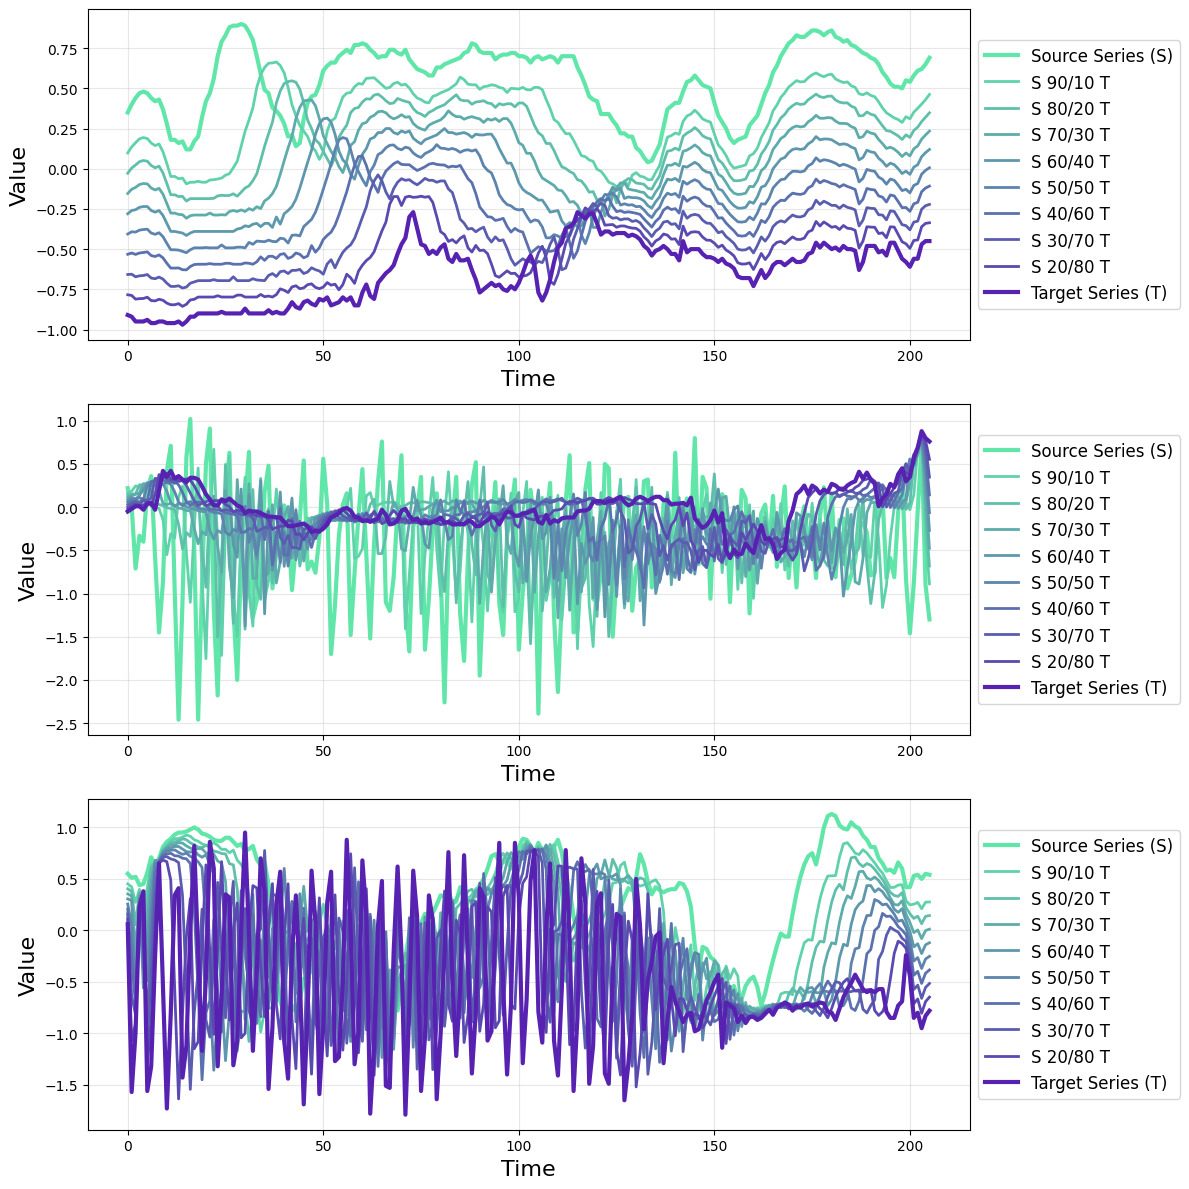

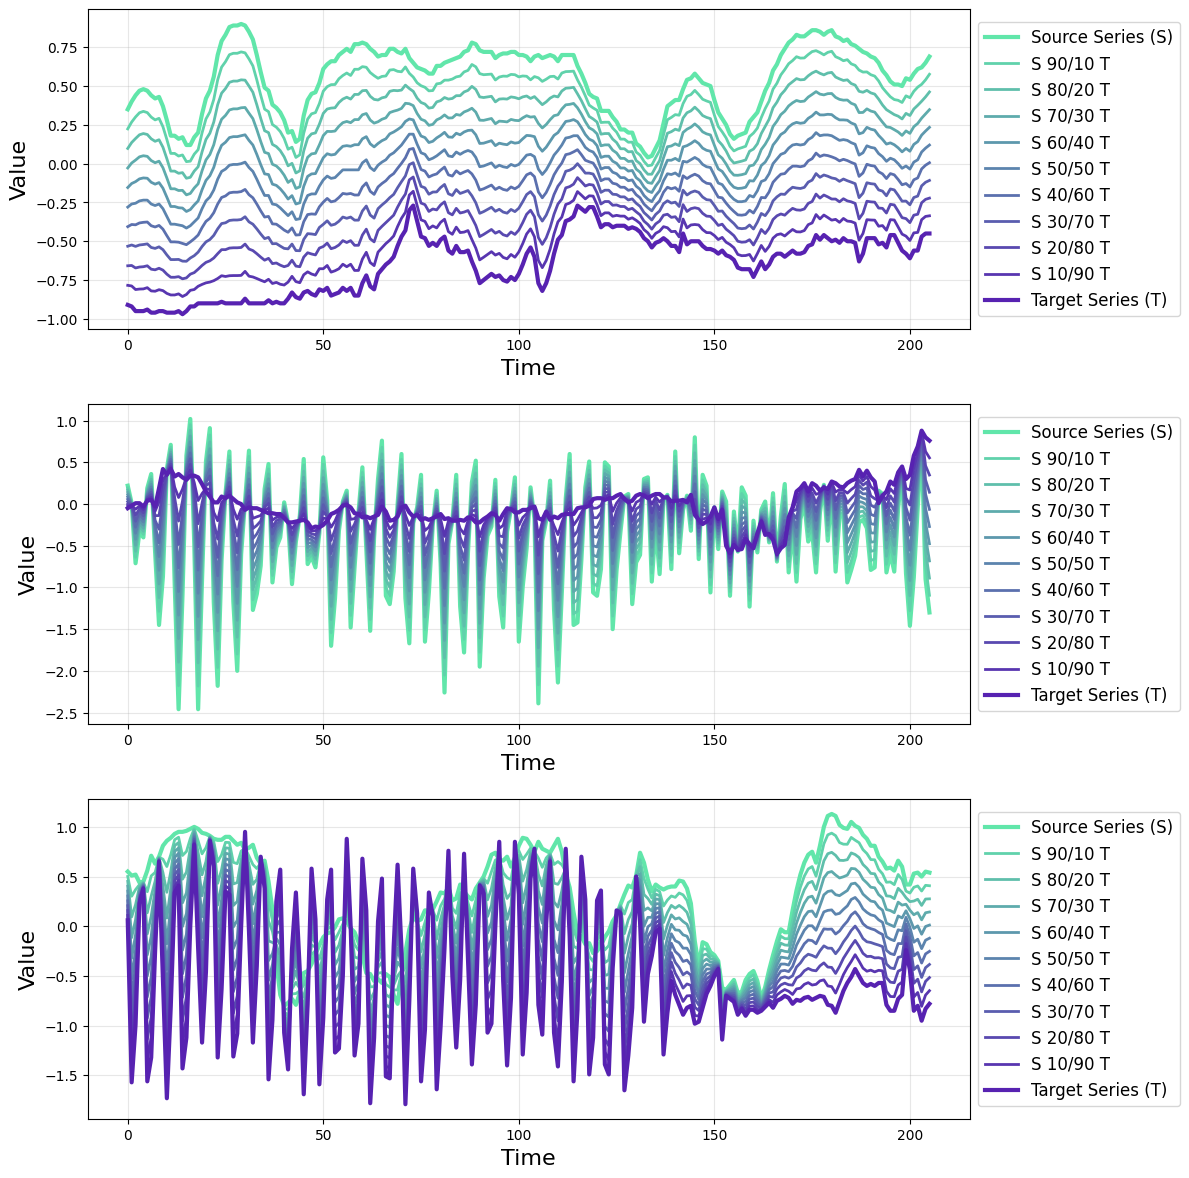

<module 'matplotlib.pyplot' from 'd:\\Feedzai\\Feedzai_laptop\\Desktop\\Mist\\MY_mist\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [ ]:
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from source.tsmorph import TSmorph

df_name = 'Epilepsy'

X, y = load_classification(df_name)
le = LabelEncoder()
y = le.fit_transform(y)

source_idx = 0
target_idx = 1

mor = TSmorph(X[source_idx], X[target_idx], 9)
morphs = mor.transform(use_dba=True)
mor.plot_morphed_series(morphs, title=False)

morphs = mor.transform()
mor.plot_morphed_series(morphs, title=False)

## Morph Comparison Plots

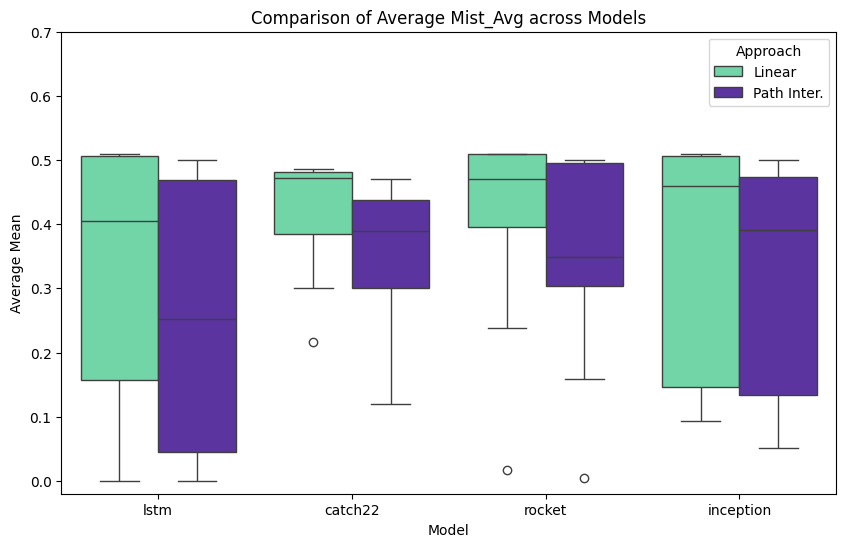

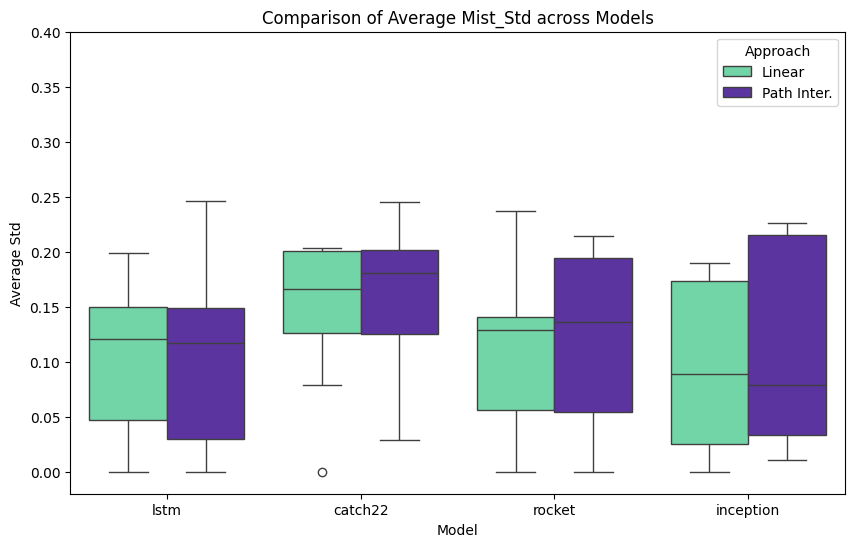

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_linear = pd.read_csv('final/linear/aggregated_linear.csv')
df_nonlinear = pd.read_csv('final/pathi/aggregated_pathi.csv')
df_linear['Approach'] = 'Linear'
df_nonlinear['Approach'] = 'Path Inter.'

my_palette = ["#61E6AA", "#5722B1"]

df_combined = pd.concat([df_linear, df_nonlinear], ignore_index=True)
model_order = ['lstm', 'catch22', 'rocket', 'inception']
df_combined['model'] = pd.Categorical(df_combined['model'], categories=model_order, ordered=True)


# Boxplot for Average Mean
plt.figure(figsize=(10, 6))
plt.ylim(-0.02, 0.7)
sns.boxplot(x='model', y='mean_of_metric_mean', hue='Approach', data=df_combined, palette=my_palette)
plt.title('Comparison of Average Mist_Avg across Models')
plt.ylabel('Average Mean')
plt.xlabel('Model')
plt.savefig('boxplot_mean.png')

# Boxplot for Average Std
plt.figure(figsize=(10, 6))
plt.ylim(-0.02, 0.4)
sns.boxplot(x='model', y='mean_of_metric_std', hue='Approach', data=df_combined, palette=my_palette)
plt.title('Comparison of Average Mist_Std across Models')
plt.ylabel('Average Std')
plt.xlabel('Model')
plt.savefig('boxplot_std.png')